In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot
import seaborn as sns

In [ ]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [ ]:
df.shape

(7043, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


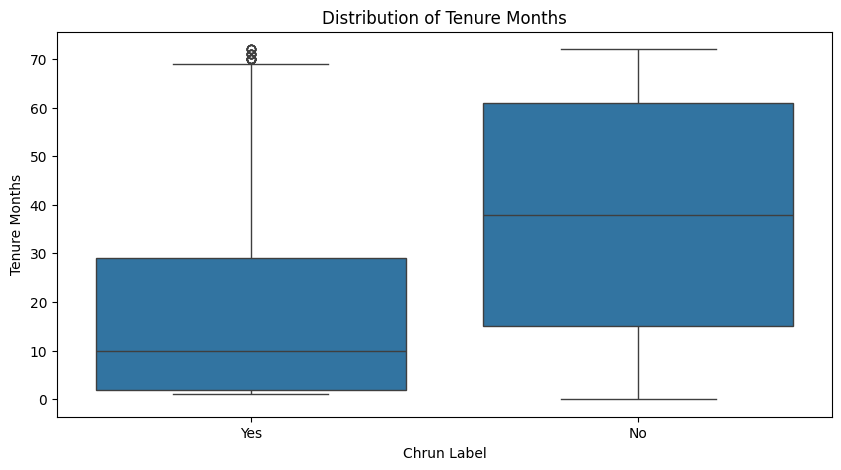

In [ ]:
plot.figure(figsize=(10,5))
sns.boxplot(x ='Churn Label',y = 'Tenure Months',data = df)
plot.xlabel('Chrun Label')
plot.ylabel('Tenure Months')
plot.title('Distribution of Tenure Months')
plot.show()

In [ ]:
df['Tenure Months'].max()
#it will tell x axis max value


72

In [ ]:
df['Tenure Months'].min()
#it will tell x axis min value


0

In [ ]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

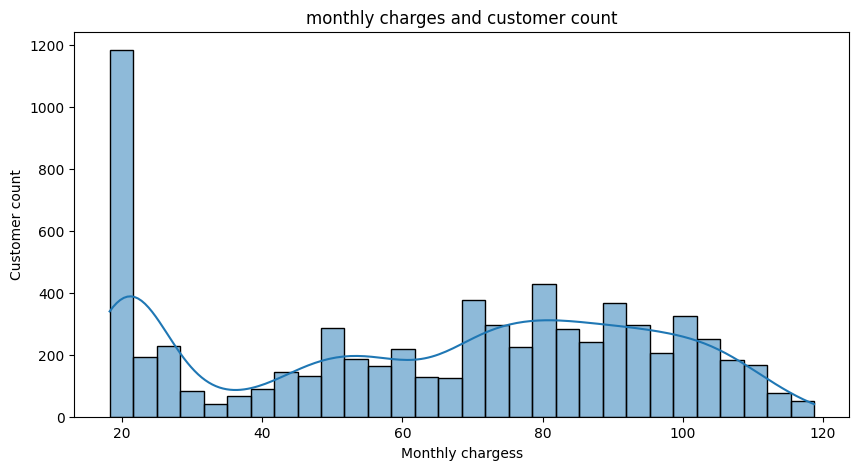

In [ ]:
plot.figure(figsize=(10,5))
sns.histplot(x ='Monthly Charges',data = df,kde =True,bins = 30)
plot.xlabel('Monthly chargess')
plot.ylabel('Customer count')
plot.title('monthly charges and customer count')
plot.show()

In [ ]:
df['Monthly Charges'].max()

118.75

In [ ]:
df['Monthly Charges'].min()

18.25

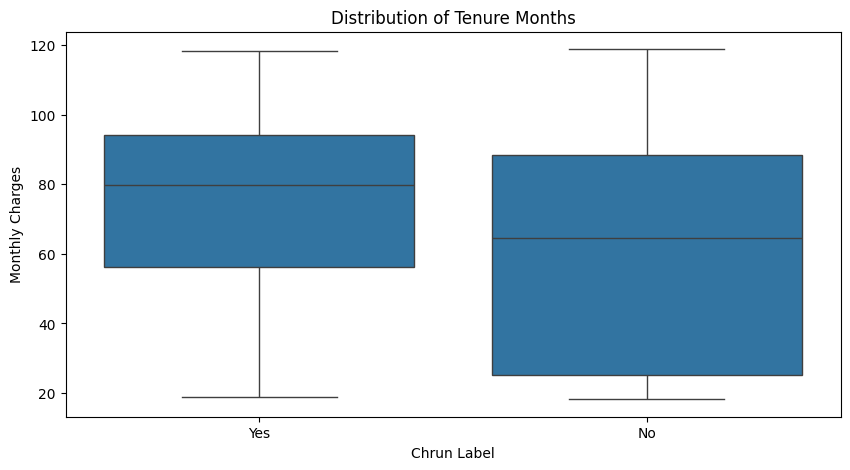

In [ ]:
plot.figure(figsize=(10,5))
sns.boxplot(x ='Churn Label',y = 'Monthly Charges',data = df)
plot.xlabel('Chrun Label')
plot.ylabel('Monthly Charges')
plot.title('Distribution of Tenure Months')
plot.show()

In [ ]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [ ]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [ ]:
df["Monthly Charges"].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [ ]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

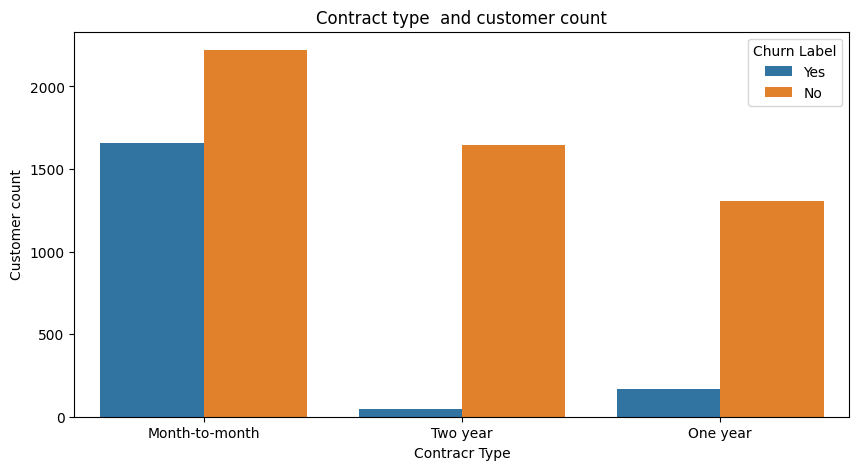

In [ ]:
plot.figure(figsize=(10,5))
sns.countplot(x ='Contract',hue='Churn Label',data = df)
plot.xlabel('Contracr Type')
plot.ylabel('Customer count')
plot.title('Contract type  and customer count')
plot.show()

In [ ]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


In [ ]:
df[df['Churn Label']=='No']['Monthly Charges'].mean()

np.float64(61.26512369540008)

In [ ]:
df[df['Churn Label']=='Yes']['Monthly Charges'].mean()

np.float64(74.44133226324237)

In [ ]:
df.groupby('Churn Label')['Monthly Charges'].mean()

,Monthly Charges
Churn Label,
No,61.265124
Yes,74.441332


In [ ]:
contract_churn = pd.crosstab(df['Contract'], df['Churn Label'])
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [ ]:
numerical_cols = ['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']
correlation_matrix = df[numerical_cols].corr()
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [ ]:
pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')
#normalise = index means it gives % row wise

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [ ]:
pd.crosstab(df['Contract'], df['Churn Label'], normalize='columns')
#normalise = index means it gives % column wise

Churn Label,No,Yes
Contract,,
Month-to-month,0.429068,0.885500
One year,0.252609,0.088818
Two year,0.318322,0.025682


In [ ]:
df['Total Charges']
#data type should be int but instead of object

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [ ]:
#pd.to_numeric(df['Total Charges'], errors='coerce')
# coerce converts invalid or blank string values to NaN so that no error is thrown.

In [ ]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months


In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(0,)

In [ ]:
df['Total Charges']= df[ 'Total Charges'].fillna(0)

In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(0,)

In [ ]:
drop_column = ['CustomerID', 'Count', 'Zip Code', 'Latitude', 'Longitude', 'Churn Label', 'Churn Score', 'Churn Reason', 'CLTV', 'Country', 'State', 'Lat Long']

In [ ]:
df = df.drop(columns=drop_column, errors='ignore')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [ ]:
df = pd.read_excel("Telco_customer_churn.xlsx")

The DataFrame has been reloaded to its original state. Now, I will re-apply the column dropping, making sure to keep the 'City' column based on your previous instruction.

In [ ]:
df = df.drop(columns=drop_column, errors='ignore')

Let's check the DataFrame information to confirm that 'City' column is now present and other specified columns are dropped.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [ ]:
df_encode = pd.get_dummies(df,drop_first=True)

In [ ]:
df = df.drop(columns = 'City',errors='ignore')

In [ ]:
df_encode = pd.get_dummies(df,drop_first=True)

In [ ]:
df_encode.shape


(7043, 6560)

Let's first review the `info()` of the `df` *before* encoding to see its current columns and their data types. Then we can look at the unique values in the object-type columns, which are the ones `pd.get_dummies` will expand.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

Now, let's examine the number of unique values in each categorical column (`object` dtype) in `df`. Columns with a high number of unique values will result in a large number of new columns after `pd.get_dummies`.

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"Column '{col}': {df[col].nunique()} unique values")

Column 'Gender': 2 unique values
Column 'Senior Citizen': 2 unique values
Column 'Partner': 2 unique values
Column 'Dependents': 2 unique values
Column 'Phone Service': 2 unique values
Column 'Multiple Lines': 3 unique values
Column 'Internet Service': 3 unique values
Column 'Online Security': 3 unique values
Column 'Online Backup': 3 unique values
Column 'Device Protection': 3 unique values
Column 'Tech Support': 3 unique values
Column 'Streaming TV': 3 unique values
Column 'Streaming Movies': 3 unique values
Column 'Contract': 3 unique values
Column 'Paperless Billing': 2 unique values
Column 'Payment Method': 4 unique values
Column 'Total Charges': 6531 unique values


You can see that the 'Total Charges' column, although currently an 'object' type, appears to contain numerical data. If it has a large number of unique values, `pd.get_dummies` will create a new column for each unique value, which could significantly increase the column count. It would be beneficial to convert 'Total Charges' to a numeric type before encoding. Also, columns like 'Payment Method' and 'Contract' also contribute multiple columns but 'Total Charges' will likely be the biggest contributor to the high column count if not converted.

In [ ]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [ ]:
df['Total Charges'] = df['Total Charges'].fillna(0)

Now that 'Total Charges' has been converted to a numeric type and any potential NaN values have been handled, let's re-check the `df.info()` to confirm the data type and the unique values in the remaining object columns.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"Column '{col}': {df[col].nunique()} unique values")

Column 'Gender': 2 unique values
Column 'Senior Citizen': 2 unique values
Column 'Partner': 2 unique values
Column 'Dependents': 2 unique values
Column 'Phone Service': 2 unique values
Column 'Multiple Lines': 3 unique values
Column 'Internet Service': 3 unique values
Column 'Online Security': 3 unique values
Column 'Online Backup': 3 unique values
Column 'Device Protection': 3 unique values
Column 'Tech Support': 3 unique values
Column 'Streaming TV': 3 unique values
Column 'Streaming Movies': 3 unique values
Column 'Contract': 3 unique values
Column 'Paperless Billing': 2 unique values
Column 'Payment Method': 4 unique values


Now that 'Total Charges' has been converted to a numeric type, let's re-run `pd.get_dummies` and check the shape of `df_encode` again. You should see a much lower number of columns.

In [ ]:
df_encode = pd.get_dummies(df, drop_first=True)

In [ ]:
df_encode.shape

(7043, 31)

In [ ]:
X = df_encode.drop(columns='Churn Value',axis = 1)
y = df_encode['Churn Value']

In [ ]:
X.shape
y.shape
print(X)
print(y)

      Tenure Months  Monthly Charges  Total Charges  Gender_Male  \
0                 2            53.85         108.15         True   
1                 2            70.70         151.65        False   
2                 8            99.65         820.50        False   
3                28           104.80        3046.05        False   
4                49           103.70        5036.30         True   
...             ...              ...            ...          ...   
7038             72            21.15        1419.40        False   
7039             24            84.80        1990.50         True   
7040             72           103.20        7362.90        False   
7041             11            29.60         346.45        False   
7042             66           105.65        6844.50         True   

      Senior Citizen_Yes  Partner_Yes  Dependents_Yes  Phone Service_Yes  \
0                  False        False           False               True   
1                  False       

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_test
X_train
Y_test
Y_train

,Churn Value
2142,0
1623,1
6074,0
1362,1
6754,0
...,...
3772,0
5191,0
5226,0
5390,0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
y_pred


array([0, 0, 0, ..., 1, 0, 1])

In [ ]:
Y_test

,Churn Value
185,1
2715,0
3825,0
1807,1
132,1
...,...
6366,0
315,1
2439,0
5002,0


In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(Y_test, y_pred))

Accuracy: 0.7856635911994322


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred)

In [ ]:
print(cm)

[[902 107]
 [195 205]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Random Forest with class imbalance handling
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

# Train model
rf_balanced.fit(X_train, Y_train)

# Predictions
y_pred_balanced = rf_balanced.predict(X_test)

# Accuracy
accuracy_balanced = accuracy_score(Y_test, y_pred_balanced)

# Confusion Matrix
cm_balanced = confusion_matrix(Y_test, y_pred_balanced)

# Print results
print("Accuracy :", accuracy_balanced)
print("\nConfusion Matrix :")
print(cm_balanced)

print("\nClassification Report :")
print(classification_report(Y_test, y_pred_balanced))

Accuracy : 0.7920511000709723

Confusion Matrix :
[[907 102]
 [191 209]]

Classification Report :
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [ ]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_tuned.fit(X_train, Y_train)

y_pred_tuned = rf_balanced.predict(X_test)

print(classification_report(Y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Features': X.columns,
    'Importance': rf_tuned.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                                  Features  Importance
0                            Tenure Months    0.179069
2                            Total Charges    0.136460
25                       Contract_Two year    0.102861
1                          Monthly Charges    0.093681
6                           Dependents_Yes    0.068517
10            Internet Service_Fiber optic    0.060228
28         Payment Method_Electronic check    0.046732
24                       Contract_One year    0.036682
13                     Online Security_Yes    0.029356
19                        Tech Support_Yes    0.021106
26                   Paperless Billing_Yes    0.018064
5                              Partner_Yes    0.015846
12     Online Security_No internet service    0.014973
18        Tech Support_No internet service    0.014799
22    Streaming Movies_No internet service    0.014360
16   Device Protection_No internet service    0.012985
11                     Internet Service_No    0.012673
3         

In [ ]:
# ======================================================
# Feature Selection + Random Forest Training + Evaluation
# ======================================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# ------------------------------------------------------
# Drop less important features
# ------------------------------------------------------

X_selected = X.drop(
    ['Phone Service_Yes', 'Multiple Lines_No phone service'],
    axis=1
)

# ------------------------------------------------------
# Train-Test Split
# ------------------------------------------------------

X_train_sel, X_test_sel, Y_train_sel, Y_test_sel = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------------
# Random Forest Model
# ------------------------------------------------------

rf_selected = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

# ------------------------------------------------------
# Train Model
# ------------------------------------------------------

rf_selected.fit(X_train_sel, Y_train_sel)

# ------------------------------------------------------
# Predictions
# ------------------------------------------------------

y_pred_selected = rf_selected.predict(X_test_sel)

# ------------------------------------------------------
# Evaluation
# ------------------------------------------------------

print("Classification Report:\n")
print(classification_report(Y_test_sel, y_pred_selected))

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import pandas as pd

# Different hyperparameter values
n_estimators_list = [100, 200, 300, 400, 500]
max_depth_list = [5, 10, 15, 20]

results = []

for n_trees in n_estimators_list:
    for depth in max_depth_list:

        rf = RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=depth,
            random_state=42,
            class_weight='balanced'
        )

        rf.fit(X_train, Y_train)

        y_pred = rf.predict(X_test)

        accuracy = accuracy_score(Y_test, y_pred)
        recall = recall_score(Y_test, y_pred)
        precision = precision_score(Y_test, y_pred)
        f1 = f1_score(Y_test, y_pred)

        results.append({
            'Trees': n_trees,
            'Depth': depth,
            'Accuracy': accuracy,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1
        })

# Convert list to DataFrame
result_df = pd.DataFrame(results)

# Sort by Recall first, then Accuracy
result_df = result_df.sort_values(
    by=['Recall', 'Accuracy'],
    ascending=False
)

# Show top 20 combinations
print(result_df.head(20))

    Trees  Depth  Accuracy  Recall  Precision  F1 Score
0     100      5  0.745919  0.8200   0.534202  0.646943
8     300      5  0.743790  0.8200   0.531605  0.645034
12    400      5  0.743790  0.8125   0.531915  0.642928
4     200      5  0.742370  0.8100   0.530278  0.640950
16    500      5  0.740951  0.8050   0.528736  0.638256
1     100     10  0.775727  0.7525   0.581081  0.655773
9     300     10  0.782825  0.7475   0.593254  0.661504
13    400     10  0.782825  0.7475   0.593254  0.661504
17    500     10  0.781405  0.7475   0.590909  0.660044
5     200     10  0.782115  0.7450   0.592445  0.660022
10    300     15  0.806246  0.6400   0.664935  0.652229
14    400     15  0.803407  0.6375   0.658915  0.648030
18    500     15  0.801987  0.6375   0.655527  0.646388
6     200     15  0.804826  0.6350   0.663185  0.648787
2     100     15  0.802697  0.6300   0.659686  0.644501
3     100     20  0.787793  0.5325   0.655385  0.587586
7     200     20  0.793471  0.5275   0.674121  0

In [ ]:
from sklearn.model_selection import cross_val_score

# Using the rf_tuned model as final_rf
final_rf = rf_tuned

cv_accuracy = cross_val_score(
    final_rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

cv_accuracy
cv_accuracy.mean()

np.float64(0.7793569343183432)

In [ ]:
from sklearn.model_selection import cross_val_score

cv_recall = cross_val_score(
    final_rf,
    X,
    y,
    cv=5,
    scoring='recall'
)

cv_recall
cv_recall.mean()

np.float64(0.7335350030823931)

In [ ]:
y_prob1 = rf_tuned.predict_proba(X_test)

churn_prob = y_prob1[:,1]
y_prob1 = rf_tuned.predict_proba(X_test)
y_prob = rf_tuned.predict_proba(X)

churn_probability = y_prob[:,1]

In [ ]:
segmentation_data = pd.DataFrame({
    'Tenure Months': X['Tenure Months'],
    'Monthly Charges': X['Monthly Charges'],
    'Total Charges': X['Total Charges'],
    'Churn Probability': churn_probability
})

In [ ]:
from sklearn.preprocessing import StandardScaler

scaled_data = StandardScaler().fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   1.02486837]
 [-1.23672422  0.19736523 -0.93887444  1.4138535 ]
 [-0.99240204  1.1595457  -0.64378925  1.44591771]
 [-0.17799476  1.33071079  0.3380854   0.65260685]
 [ 0.67713287  1.29415125  1.2161497   0.50375182]]


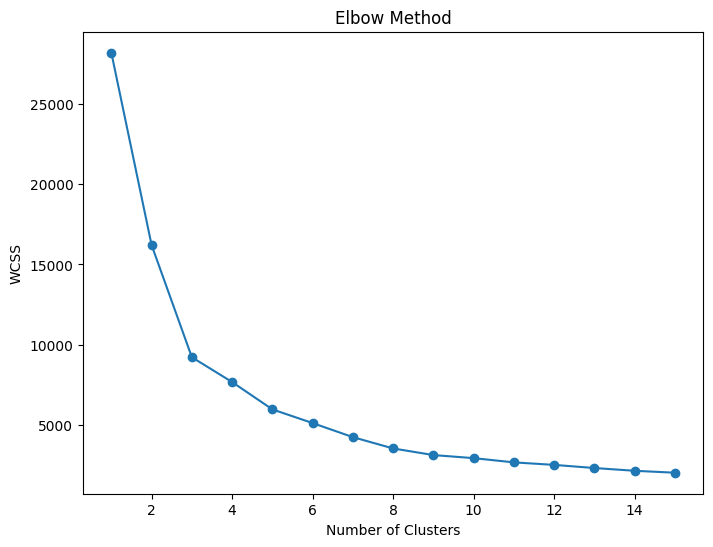

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1,16), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

print(clusters)

[1 1 1 ... 2 0 2]


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

print(df.head())

   Gender Senior Citizen Partner Dependents  Tenure Months Phone Service  \
0    Male             No      No         No              2           Yes   
1  Female             No      No        Yes              2           Yes   
2  Female             No      No        Yes              8           Yes   
3  Female             No     Yes        Yes             28           Yes   
4    Male             No      No        Yes             49           Yes   

  Multiple Lines Internet Service Online Security Online Backup  ...  \
0             No              DSL             Yes           Yes  ...   
1             No      Fiber optic              No            No  ...   
2            Yes      Fiber optic              No            No  ...   
3            Yes      Fiber optic              No            No  ...   
4            Yes      Fiber optic              No           Yes  ...   

  Tech Support Streaming TV Streaming Movies        Contract  \
0           No           No               No  

In [ ]:
segmentation_data['Cluster'] = clusters

segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
0,2,53.85,108.15,0.676963,1
1,2,70.70,151.65,0.796013,1
2,8,99.65,820.50,0.805827,1
3,28,104.80,3046.05,0.563031,1
4,49,103.70,5036.30,0.517474,2
...,...,...,...,...,...
7038,72,21.15,1419.40,0.003587,0
7039,24,84.80,1990.50,0.082095,0
7040,72,103.20,7362.90,0.049001,2
7041,11,29.60,346.45,0.302367,0


In [ ]:
cluster_summary = segmentation_data.groupby('Cluster').mean()

cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,32.051471,32.845761,1047.702141,0.120599
1,10.957752,71.961298,884.069671,0.691383
2,58.398884,90.430986,5278.001674,0.230647


In [ ]:
cluster_names = {
    0: 'Budget Loyal Customers',
    1: 'High Risk New Customers',
    2: 'Loyal Premium Customers'
}

segmentation_data['Segment'] = segmentation_data['Cluster'].map(cluster_names)

segmentation_data.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Segment
0,2,53.85,108.15,0.676963,1,High Risk New Customers
1,2,70.70,151.65,0.796013,1,High Risk New Customers
2,8,99.65,820.50,0.805827,1,High Risk New Customers
3,28,104.80,3046.05,0.563031,1,High Risk New Customers
4,49,103.70,5036.30,0.517474,2,Loyal Premium Customers


In [ ]:
print(segmentation_data.columns.tolist())

['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Probability', 'Cluster', 'Segment']


In [ ]:
print(segmentation_data.head())

   Tenure Months  Monthly Charges  Total Charges  Churn Probability  Cluster  \
0              2            53.85         108.15           0.676963        1   
1              2            70.70         151.65           0.796013        1   
2              8            99.65         820.50           0.805827        1   
3             28           104.80        3046.05           0.563031        1   
4             49           103.70        5036.30           0.517474        2   

                   Segment  
0  High Risk New Customers  
1  High Risk New Customers  
2  High Risk New Customers  
3  High Risk New Customers  
4  Loyal Premium Customers  


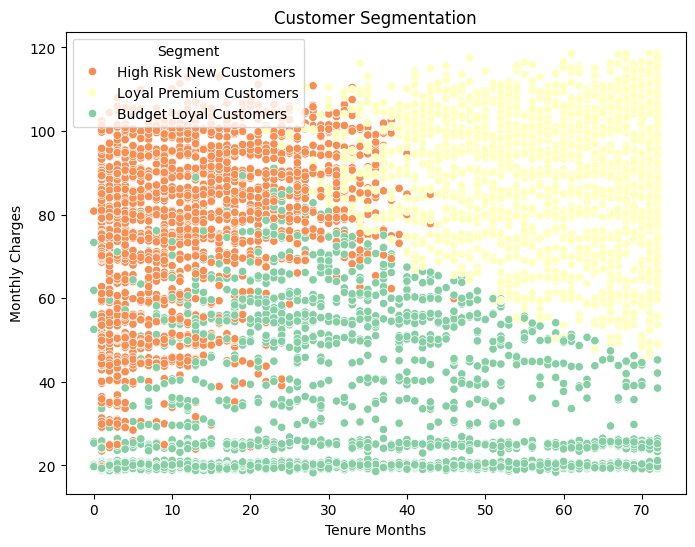

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='Tenure Months',
    y='Monthly Charges',
    hue='Segment',
    data=segmentation_data,
    palette='Spectral'
)

plt.title('Customer Segmentation')
plt.xlabel('Tenure Months')
plt.ylabel('Monthly Charges')
plt.legend(title='Segment')
plt.show()

In [ ]:
segmentation_data['Churn Probability'] = (
    1 - segmentation_data['Tenure Months'] /
    segmentation_data['Tenure Months'].max()
)

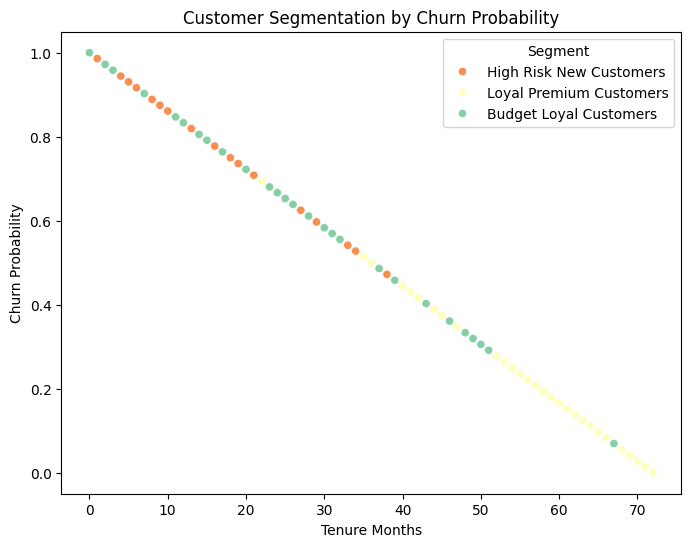

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=segmentation_data,
    x='Tenure Months',
    y='Churn Probability',
    hue='Segment',
    palette='Spectral'
)

plt.title('Customer Segmentation by Churn Probability')
plt.xlabel('Tenure Months')
plt.ylabel('Churn Probability')
plt.legend(title='Segment')

plt.show()